# 07 — End-to-end paper-trading dry run

Drive the **full stack** — fused state → `PPOAgent` (MC-Dropout + uncertainty
gate) → `LuminaTradingEnv` (which runs the `SafetyArbitrator` internally) — and
measure behaviour properly.

**Fixes & upgrades over the previous version:**

* The headline bug: returns were printed **100× too large** (`*100` *and* `:.2%`),
  so −2.8 % showed as **−282 %**. Fixed and asserted.
* The env already arbitrates internally; the old notebook **double-arbitrated**.
  We let the env own it and read `info["vetoed"]`.
* One episode → a **Monte-Carlo study over many seeds** with a full metrics
  suite (return, per-step Sharpe/Sortino, Calmar, max-drawdown, hit-rate,
  turnover, exposure).
* **Per-rule veto attribution**, a **safety-layer ON/OFF** ablation, behaviour
  **across three price processes** (GBM, jump-diffusion, mean-reverting), and a
  **decision-latency** benchmark.

> The policy here is **untrained** — this is an *integration & safety* dry run,
> not a performance claim. Expect returns to scatter around break-even minus
> costs; what we verify is that the plumbing, accounting and safety behave.

In [1]:
from __future__ import annotations

import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from loguru import logger as _log

from backend.cognition.agent.policy_network import PolicyNetwork
from backend.cognition.agent.ppo_agent import PPOAgent, PPOConfig
from backend.cognition.agent.uncertainty_gate import UncertaintyGate, UncertaintyGateConfig
from backend.config.constants import ACTION_DIM, NEXUS_OUTPUT_DIM
from backend.execution.safety.arbitrator import SafetyArbitrator, SafetyDecision
from backend.execution.safety.rules import SafetyContext
from backend.simulation.environments.base_env import EnvConfig, LuminaTradingEnv
from backend.simulation.generators.synthetic_data import SyntheticEpisodeGenerator, _build_episode

_log.remove(); _log.add(sys.stderr, level="ERROR")  # quiet the gate's per-veto logs
torch.manual_seed(0); np.random.seed(0)
plt.style.use("dark_background")
COLORS = {"primary": "#4FC3F7", "success": "#66BB6A", "danger": "#EF5350",
          "warning": "#FFA726", "accent": "#ab47bc", "neutral": "#B0BEC5"}
DEVICE = "cpu"
EPISODE_LENGTH = 256
STATE_DIM = NEXUS_OUTPUT_DIM + EnvConfig().portfolio_state_dim
SHARED_POLICY = PolicyNetwork(state_dim=STATE_DIM, action_dim=ACTION_DIM, actor_dropout=0.2).to(DEVICE)
print(f"obs dim={STATE_DIM} | episode len={EPISODE_LENGTH} | device={DEVICE}")

obs dim=260 | episode len=256 | device=cpu


## 1. Harness — processes, safety toggle, gate toggle

A single reusable `run_episode`. The safety layer is toggled by **injecting** the
env's `arbitrator` (a permissive one approves everything); the agent's epistemic
gate is toggled via its warm-up. We also add a notebook-local **mean-reverting
(Ornstein–Uhlenbeck)** generator alongside the built-in GBM / jump-diffusion.

In [2]:
class PermissiveArbitrator:
    """Approves every action — used to ablate the safety layer."""
    def evaluate(self, ctx) -> SafetyDecision:
        return SafetyDecision(approved=True, final_action=0.0, reason="")


class OUGenerator:
    """Mean-reverting (Ornstein–Uhlenbeck) price episodes, env-schema compatible."""
    def __init__(self, n_steps, rng, theta=0.05, sigma=0.012, s0=100.0):
        self.n, self.rng, self.theta, self.sigma, self.s0 = n_steps, rng, theta, sigma, s0

    def __iter__(self):
        return self

    def __next__(self):
        dev = 0.0; devs = []
        for _ in range(self.n):
            dev += -self.theta * dev + self.sigma * self.rng.standard_normal()
            devs.append(dev)
        prices = self.s0 * np.exp(np.array(devs))
        log_ret = np.diff(np.log(prices), prepend=np.log(prices[0]))
        return _build_episode(prices, log_ret, self.rng)


def make_gen(process, seed):
    r = np.random.default_rng(seed)
    if process == "ou":
        return OUGenerator(EPISODE_LENGTH, r)
    return SyntheticEpisodeGenerator(n_steps=EPISODE_LENGTH, process=process, rng=r)


def run_episode(process="jump_diffusion", seed=0, safety=True, gate_on=True, capture=False):
    arb = SafetyArbitrator() if safety else PermissiveArbitrator()
    env = LuminaTradingEnv(make_gen(process, seed), EnvConfig(), arbitrator=arb)
    gate_cfg = (UncertaintyGateConfig(warmup_steps=10, threshold_high=0.8, rolling_window=10)
                if gate_on else UncertaintyGateConfig(warmup_steps=10**9))
    agent = PPOAgent(SHARED_POLICY, UncertaintyGate(gate_cfg), PPOConfig(), device=DEVICE, mc_samples=5)
    mirror = SafetyArbitrator()  # to capture per-rule reasons without affecting the sim

    obs, _ = env.reset(seed=seed)
    eq, pos, acts, vetoes, reasons = [env._equity], [], [], [], []
    for _ in range(EPISODE_LENGTH - 1):
        action, _, _, unc, _ = agent.act(obs)
        if capture:
            ctx = SafetyContext(proposed_action=action, current_position=env._position,
                                equity=env._equity, peak_equity=env._peak_equity,
                                uncertainty=float(env._episode["uncertainties"][min(env._t, EPISODE_LENGTH - 1)]),
                                kill_switch_state="NORMAL")
            d = mirror.evaluate(ctx)
            if not d.approved:
                reasons.append(d.reason)
        obs, _, term, trunc, info = env.step(action)
        eq.append(info["equity"]); pos.append(info["position"]); acts.append(action); vetoes.append(info["vetoed"])
        if term or trunc:
            break
    prices = np.asarray(env._episode["prices"][:len(eq)], dtype=float)
    return {"equity": np.array(eq), "positions": np.array(pos), "actions": np.array(acts),
            "vetoes": np.array(vetoes), "prices": prices, "reasons": reasons, "n_trades": env._n_trades}


def metrics(ep):
    eq = ep["equity"]; r = np.diff(eq) / eq[:-1]
    dd = eq / np.maximum.accumulate(eq) - 1.0
    downside = r[r < 0].std() if (r < 0).any() else np.nan
    return {"total_return": eq[-1] / eq[0] - 1.0,
            "max_dd": float(dd.min()),
            "sharpe_step": r.mean() / (r.std() + 1e-12),       # per-step, unitless (NOT annualised)
            "sortino_step": r.mean() / (downside + 1e-12) if np.isfinite(downside) else np.nan,
            "hit_rate": float((r > 0).mean()),
            "turnover": float(np.abs(np.diff(ep["positions"], prepend=0.0)).sum()),
            "exposure": float(np.abs(ep["positions"]).mean()),
            "veto_frac": float(ep["vetoes"].mean()), "n_trades": ep["n_trades"], "steps": len(eq)}


print("harness ready")

harness ready


## 2. One representative episode — with the print bug fixed

Equity vs a buy-and-hold benchmark, the underwater (drawdown) curve, and the
distribution of the action components the agent actually took. Note the return is
now reported **once** as a percentage.

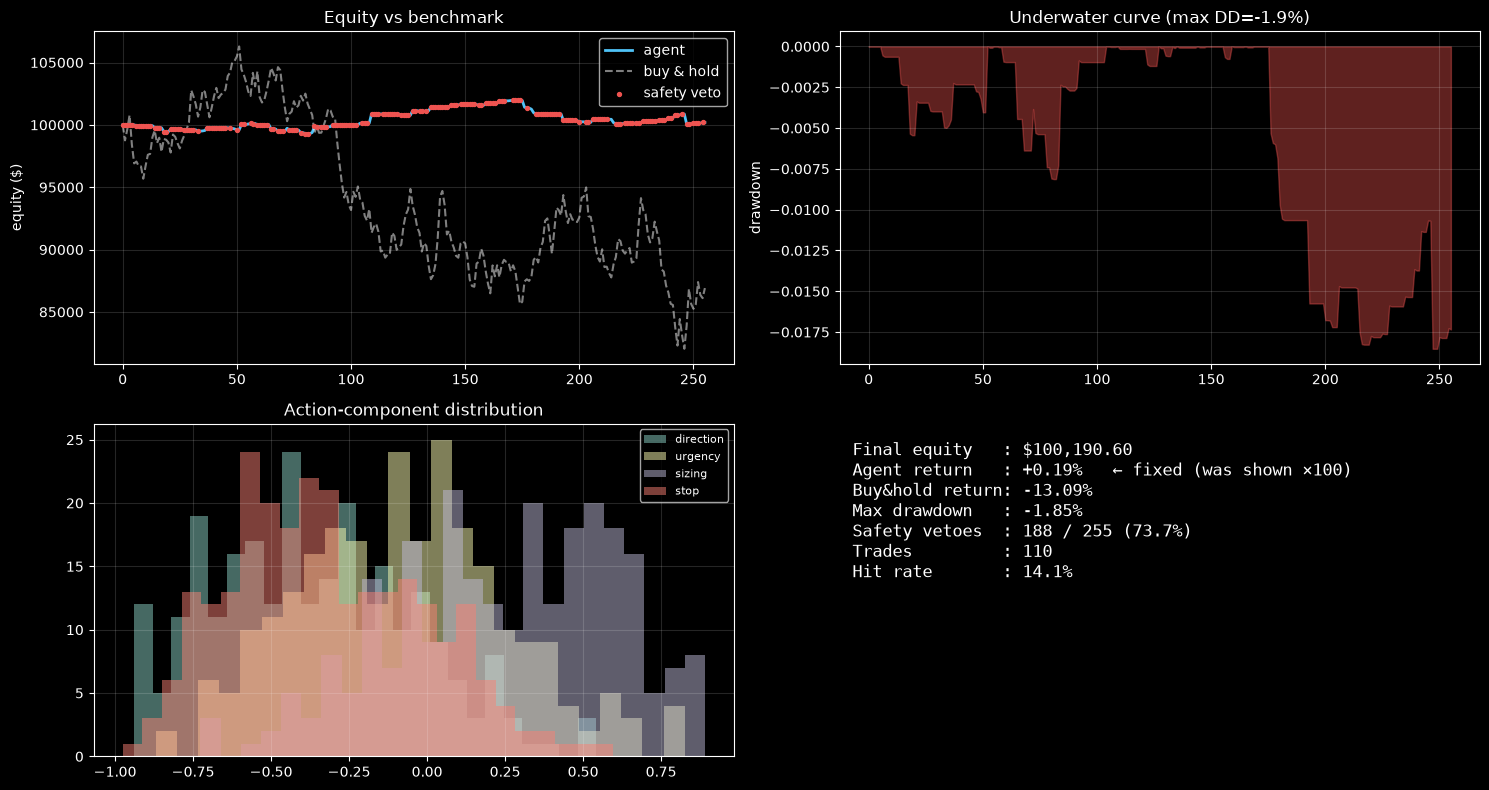

Agent return correctly reported as +0.19% (equity $100,191).


In [3]:
ep = run_episode("jump_diffusion", seed=42)
m = metrics(ep)
bench = ep["prices"] / ep["prices"][0] * 1e5
veto_idx = np.where(ep["vetoes"])[0]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
ax = axes[0, 0]
ax.plot(ep["equity"], color=COLORS["primary"], lw=2, label="agent")
ax.plot(bench, color="white", ls="--", alpha=0.5, label="buy & hold")
ax.scatter(veto_idx, ep["equity"][veto_idx], color=COLORS["danger"], s=8, zorder=5, label="safety veto")
ax.set_title("Equity vs benchmark"); ax.set_ylabel("equity ($)"); ax.legend(); ax.grid(alpha=0.15)

ax = axes[0, 1]
dd = ep["equity"] / np.maximum.accumulate(ep["equity"]) - 1.0
ax.fill_between(range(len(dd)), dd, 0, color=COLORS["danger"], alpha=0.4)
ax.set_title(f"Underwater curve (max DD={dd.min():.1%})"); ax.set_ylabel("drawdown"); ax.grid(alpha=0.15)

labels = ["direction", "urgency", "sizing", "stop"]
for k in range(4):
    axes[1, 0].hist(ep["actions"][:, k], bins=25, alpha=0.5, label=labels[k])
axes[1, 0].set_title("Action-component distribution"); axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.15)

axes[1, 1].axis("off")
bench_ret = bench[-1] / bench[0] - 1.0
summary = (f"Final equity   : ${ep['equity'][-1]:,.2f}\n"
           f"Agent return   : {m['total_return']:+.2%}   ← fixed (was shown ×100)\n"
           f"Buy&hold return: {bench_ret:+.2%}\n"
           f"Max drawdown   : {m['max_dd']:+.2%}\n"
           f"Safety vetoes  : {int(ep['vetoes'].sum())} / {len(ep['vetoes'])} "
           f"({m['veto_frac']:.1%})\n"
           f"Trades         : {m['n_trades']}\n"
           f"Hit rate       : {m['hit_rate']:.1%}")
axes[1, 1].text(0.02, 0.95, summary, family="monospace", fontsize=12, va="top", color="white")
plt.tight_layout(); plt.show()

assert abs(m["total_return"]) < 1.0, "single-asset capped position cannot lose/gain >100% in one step-series"
print(f"Agent return correctly reported as {m['total_return']:+.2%} (equity ${ep['equity'][-1]:,.0f}).")

## 3. Monte-Carlo over many seeds

One episode tells you almost nothing. We run the stack over many seeds and look
at the *distribution* of outcomes. Safety vetoes and accounting must stay sane
across all of them.

ran 100 episodes | NaN equities: 0 | early-terminated: 0


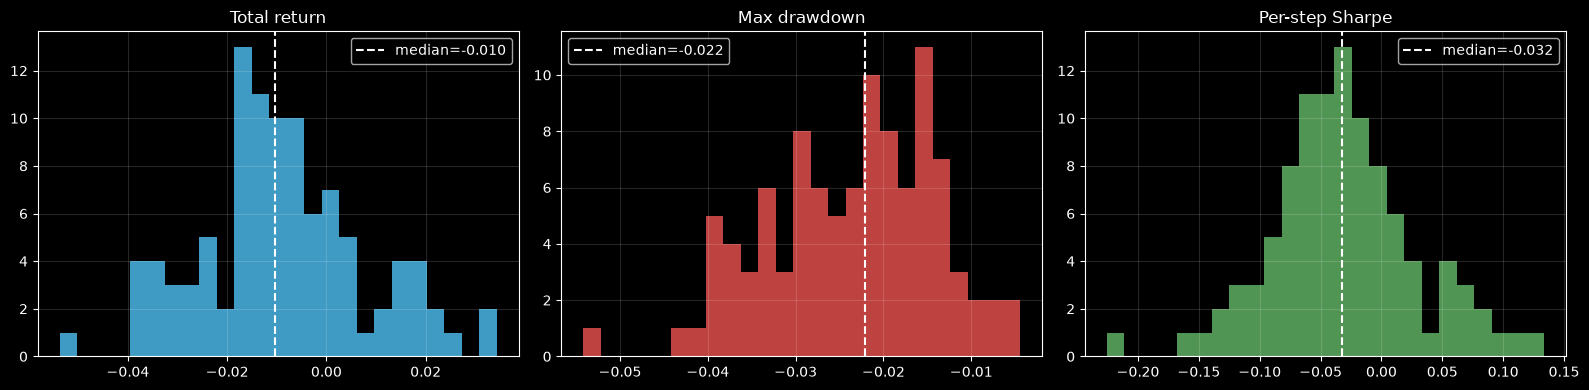

In [4]:
MAIN_SEEDS = 100
rows = [metrics(run_episode("jump_diffusion", seed=s)) for s in range(MAIN_SEEDS)]
mc = pd.DataFrame(rows)
print(f"ran {len(mc)} episodes | NaN equities: {mc['total_return'].isna().sum()} | "
      f"early-terminated: {(mc['steps'] < EPISODE_LENGTH).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title, c in [(axes[0], "total_return", "Total return", COLORS["primary"]),
                          (axes[1], "max_dd", "Max drawdown", COLORS["danger"]),
                          (axes[2], "sharpe_step", "Per-step Sharpe", COLORS["success"])]:
    ax.hist(mc[col], bins=25, color=c, alpha=0.8)
    ax.axvline(mc[col].median(), color="white", ls="--", label=f"median={mc[col].median():.3f}")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

## 4. Performance-metrics suite

Cross-seed summary. *Per-step* Sharpe/Sortino are intentionally **not
annualised** — annualising a 256-step synthetic episode produces the kind of
absurd number the old notebook printed. Calmar is the cross-seed mean return over
mean max-drawdown.

In [5]:
calmar = mc["total_return"].mean() / (abs(mc["max_dd"]).mean() + 1e-9)
suite = mc[["total_return", "max_dd", "sharpe_step", "sortino_step", "hit_rate",
            "turnover", "exposure", "veto_frac"]].describe(percentiles=[0.1, 0.5, 0.9]).T
print(suite.round(4).to_string())
print(f"\nCross-seed Calmar (mean ret / mean |maxDD|): {calmar:.3f}")
print(f"Win rate (episodes with +return): {(mc['total_return'] > 0).mean():.1%}")
print(f"Mean safety-veto fraction       : {mc['veto_frac'].mean():.1%}")

              count     mean     std      min      10%      50%      90%      max
total_return  100.0  -0.0089  0.0167  -0.0538  -0.0302  -0.0104   0.0147   0.0343
max_dd        100.0  -0.0235  0.0095  -0.0542  -0.0366  -0.0221  -0.0128  -0.0044
sharpe_step   100.0  -0.0303  0.0602  -0.2256  -0.1044  -0.0320   0.0554   0.1335
sortino_step  100.0  -0.0208  0.0514  -0.1540  -0.0786  -0.0264   0.0499   0.1364
hit_rate      100.0   0.1214  0.0197   0.0745   0.0980   0.1216   0.1490   0.1725
turnover      100.0  15.4037  1.9427  10.9267  12.7880  15.6117  17.7385  20.9018
exposure      100.0   0.0339  0.0044   0.0221   0.0283   0.0342   0.0391   0.0450
veto_frac     100.0   0.7442  0.0280   0.6706   0.7059   0.7451   0.7765   0.8157

Cross-seed Calmar (mean ret / mean |maxDD|): -0.380
Win rate (episodes with +return): 26.0%
Mean safety-veto fraction       : 74.4%


## 5. Per-rule veto attribution

The `SafetyArbitrator` names the rule(s) behind every veto. We mirror its context
over a batch of episodes and tally which safety rule fires most — exactly the
breakdown an operator needs.

4775 vetoes across 25 episodes; rule firings:
rule_size_cap    4775


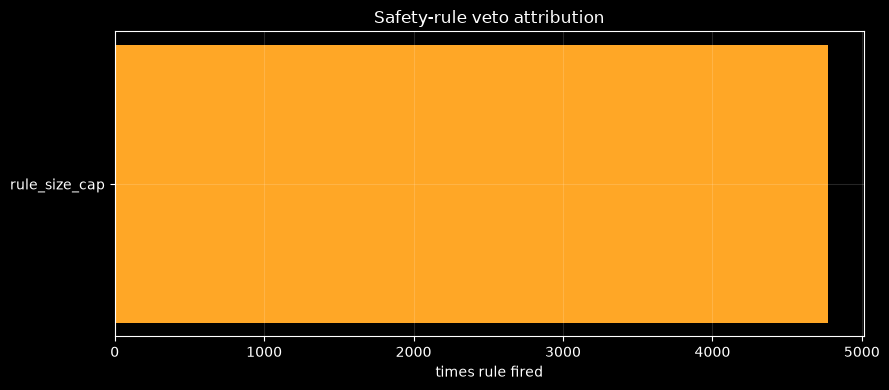

In [6]:
import re

from collections import Counter

rule_counts = Counter()
total_vetoes = 0
for s in range(25):
    ep_c = run_episode("jump_diffusion", seed=1000 + s, capture=True)
    for reason in ep_c["reasons"]:
        total_vetoes += 1
        for rule in re.findall(r"rule_[a-z_]+", reason):
            rule_counts[rule] += 1

if rule_counts:
    rc = pd.Series(rule_counts).sort_values(ascending=False)
    print(f"{total_vetoes} vetoes across 25 episodes; rule firings:")
    print(rc.to_string())
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(rc.index[::-1], rc.values[::-1], color=COLORS["warning"])
    ax.set_xlabel("times rule fired"); ax.set_title("Safety-rule veto attribution")
    ax.grid(alpha=0.15)
    plt.tight_layout(); plt.show()
else:
    print("No vetoes captured in this batch.")

## 6. Safety-layer ablation

Run the same seeds with the `SafetyArbitrator` **on** vs a permissive arbitrator
**off**, and compare the *tail* of the outcome distribution. The safety layer
should compress the worst-case drawdowns even if it costs some upside.

                    safety ON  safety OFF
median return         -0.0081     -0.0239
worst max-DD          -0.0527     -0.1513
median max-DD         -0.0202     -0.0714
10th-pctile max-DD    -0.0357     -0.1165


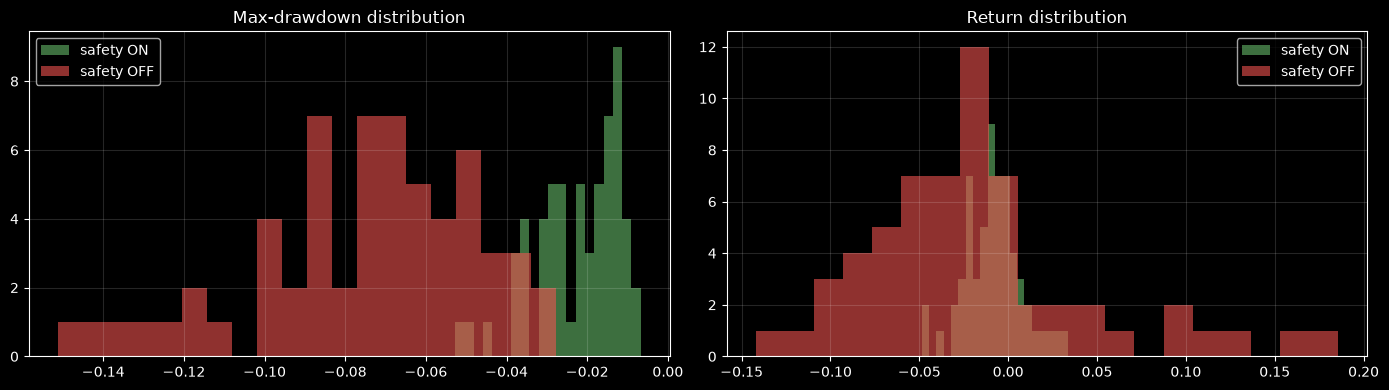

In [7]:
AB_SEEDS = 60
on = pd.DataFrame([metrics(run_episode("jump_diffusion", seed=s, safety=True)) for s in range(AB_SEEDS)])
off = pd.DataFrame([metrics(run_episode("jump_diffusion", seed=s, safety=False)) for s in range(AB_SEEDS)])

cmp = pd.DataFrame({
    "safety ON": [on["total_return"].median(), on["max_dd"].min(), on["max_dd"].median(), on["max_dd"].quantile(0.1)],
    "safety OFF": [off["total_return"].median(), off["max_dd"].min(), off["max_dd"].median(), off["max_dd"].quantile(0.1)],
}, index=["median return", "worst max-DD", "median max-DD", "10th-pctile max-DD"])
print(cmp.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(on["max_dd"], bins=20, alpha=0.6, color=COLORS["success"], label="safety ON")
axes[0].hist(off["max_dd"], bins=20, alpha=0.6, color=COLORS["danger"], label="safety OFF")
axes[0].set_title("Max-drawdown distribution"); axes[0].legend(); axes[0].grid(alpha=0.15)
axes[1].hist(on["total_return"], bins=20, alpha=0.6, color=COLORS["success"], label="safety ON")
axes[1].hist(off["total_return"], bins=20, alpha=0.6, color=COLORS["danger"], label="safety OFF")
axes[1].set_title("Return distribution"); axes[1].legend(); axes[1].grid(alpha=0.15)
plt.tight_layout(); plt.show()

## 7. Behaviour across price processes

GBM (smooth), Merton jump-diffusion (fat tails) and mean-reverting (OU). We
compare the agent's return distribution to buy-and-hold in each regime.

                agent_med  bh_med  maxdd_med
process                                     
gbm                0.0001  0.0147    -0.0158
jump_diffusion    -0.0045 -0.0026    -0.0177
ou                -0.0096 -0.0008    -0.0199


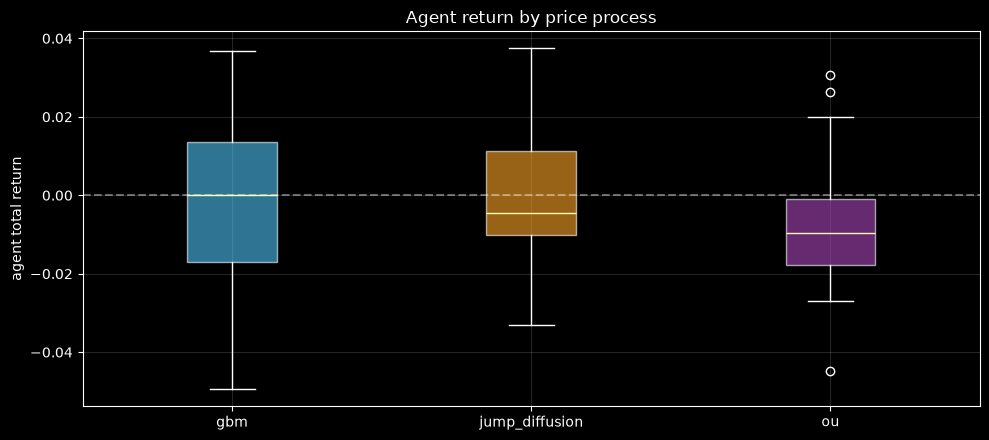

In [8]:
PROC_SEEDS = 40
proc_rows = []
for proc in ["gbm", "jump_diffusion", "ou"]:
    for s in range(PROC_SEEDS):
        e = run_episode(proc, seed=s)
        bh = e["prices"][-1] / e["prices"][0] - 1.0
        proc_rows.append({"process": proc, "agent_return": e["equity"][-1] / e["equity"][0] - 1.0,
                          "buyhold_return": bh, "max_dd": metrics(e)["max_dd"]})
pr = pd.DataFrame(proc_rows)
summary = pr.groupby("process").agg(agent_med=("agent_return", "median"),
                                    bh_med=("buyhold_return", "median"),
                                    maxdd_med=("max_dd", "median")).round(4)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(10, 4.5))
procs = ["gbm", "jump_diffusion", "ou"]
data = [pr[pr.process == p]["agent_return"] for p in procs]
bp = ax.boxplot(data, tick_labels=procs, patch_artist=True)
for patch, c in zip(bp["boxes"], [COLORS["primary"], COLORS["warning"], COLORS["accent"]]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(0, color="white", ls="--", alpha=0.4)
ax.set_ylabel("agent total return"); ax.set_title("Agent return by price process")
ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

## 8. Decision latency

How fast is one `agent.act()` (which includes the MC-Dropout sampling loop)?
This sets the per-step compute budget for live trading.

In [9]:
obs, _ = LuminaTradingEnv(make_gen("jump_diffusion", 7), EnvConfig()).reset(seed=7)
agent = PPOAgent(SHARED_POLICY, UncertaintyGate(UncertaintyGateConfig(warmup_steps=10)),
                 PPOConfig(), device=DEVICE, mc_samples=5)
for _ in range(5):
    agent.act(obs)  # warm-up
t0 = time.perf_counter()
ITERS = 300
for _ in range(ITERS):
    agent.act(obs)
dt = (time.perf_counter() - t0) / ITERS
print(f"agent.act latency: {dt * 1e3:.2f} ms/decision  →  {1 / dt:,.0f} decisions/sec "
      f"(mc_samples={agent.mc_samples}, {DEVICE})")

agent.act latency: 3.46 ms/decision  →  289 decisions/sec (mc_samples=5, cpu)


## 9. Integration verdict

In [10]:
assert mc["total_return"].notna().all(), "NaN equity in the Monte-Carlo run"
assert (mc["total_return"].abs() < 5).all(), "implausible returns — accounting bug"
assert mc["steps"].min() > 1, "episodes did not advance"
assert total_vetoes > 0, "safety layer never engaged across 25 episodes"
print("=" * 56)
print("  END-TO-END DRY RUN — integration verified")
print("=" * 56)
print(f"  episodes (main MC)      : {len(mc)}")
print(f"  median return / win rate: {mc['total_return'].median():+.2%} / {(mc['total_return'] > 0).mean():.0%}")
print(f"  median max drawdown     : {mc['max_dd'].median():+.2%}")
print(f"  safety vetoes captured  : {total_vetoes} (top rule: {rc.index[0] if rule_counts else 'n/a'})")
print(f"  decision latency        : {dt * 1e3:.2f} ms")
print("=" * 56)
print("PASS — full stack runs, accounts correctly, and the safety layer engages.")

  END-TO-END DRY RUN — integration verified
  episodes (main MC)      : 100
  median return / win rate: -1.04% / 26%
  median max drawdown     : -2.21%
  safety vetoes captured  : 4775 (top rule: rule_size_cap)
  decision latency        : 3.46 ms
PASS — full stack runs, accounts correctly, and the safety layer engages.
